In [1]:
# =========================================================
# NOTEBOOK: 15_explainable_ai_shap.ipynb
# =========================================================

# =========================================================
# STEP 1 — IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

import shap

import warnings

warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# =========================================================
# STEP 2 — LOAD DATASET
# =========================================================

master_df = pd.read_csv(
    r"C:\Users\niran\Desktop\AI_Ecommerce_Customer_Intelligence_Platform\data\processed\statistical_analysis_dataset.csv"
)

print(master_df.shape)

master_df.head()

(2530433, 87)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_duration_days,delivery_delay_days,...,Monetary,churn,product_revenue,product_total_orders,product_avg_review,product_avg_delay,seller_total_revenue,seller_total_orders,seller_avg_review,seller_avg_delay
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,...,-0.233903,0,1234480.37,724,3.800000,-8.556017,6655560.54,5121,3.952081,-9.193164
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,...,-0.233903,0,4597968.11,2719,3.779849,-16.312730,6574599.35,4999,3.996998,-18.445178
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaN,NaN,2026-01-04 08:33:20,0.037357,0.036951,...,-0.233903,0,1801075.20,2017,4.059165,-3.545635,6634183.36,4946,3.950022,-18.226289
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,0.033655,0.036951,...,-0.057950,0,1310370.47,771,3.807428,-2.662776,6668289.19,5145,3.983153,-5.763848
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,0.033655,0.036951,...,-0.057950,0,952878.10,1034,4.154799,-21.628627,6576178.28,5033,3.997017,-12.790185


In [3]:
# =========================================================
# STEP 3 — SELECT FEATURES
# =========================================================

drop_columns = [

    'order_id',
    'customer_id',
    'customer_unique_id',
    'product_id',
    'seller_id',
    'review_id',

    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

target_column = 'churn'

X = master_df.drop(
    columns=drop_columns + [target_column],
    errors='ignore'
)

y = master_df[target_column]

print(X.shape)
print(y.shape)

(2530433, 73)
(2530433,)


In [5]:
# =========================================================
# STEP 4 — HANDLE CATEGORICAL FEATURES
# =========================================================

from sklearn.preprocessing import LabelEncoder

categorical_columns = X.select_dtypes(
    include=['object']
).columns

print("Categorical Columns:")

print(categorical_columns)

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

print("Label Encoding Completed")

print(X.shape)

Categorical Columns:
Index(['order_status', 'customer_city', 'customer_state',
       'shipping_limit_date', 'product_name', 'seller_contact_gender',
       'seller_city', 'seller_state'],
      dtype='object')
Label Encoding Completed
(2530433, 73)


In [6]:
# =========================================================
# STEP 5 — TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2024346, 73)
(506087, 73)


In [7]:
# =========================================================
# STEP 6 — TRAIN XGBOOST MODEL
# =========================================================

model = XGBClassifier( n_estimators=100,
                       max_depth=6,
                       learning_rate=0.1,
                       subsample=0.8,
                       colsample_bytree=0.8,
                       random_state=42,
                       eval_metric='logloss')

model.fit( X_train, y_train)

print("XGBoost Model Trained")

XGBoost Model Trained


In [8]:
# =========================================================
# STEP 7 — MODEL EVALUATION
# =========================================================

y_pred = model.predict(X_test)

accuracy = accuracy_score( y_test, y_pred )

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print( classification_report( y_test, y_pred ))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    198690
           1       1.00      1.00      1.00    307397

    accuracy                           1.00    506087
   macro avg       1.00      1.00      1.00    506087
weighted avg       1.00      1.00      1.00    506087



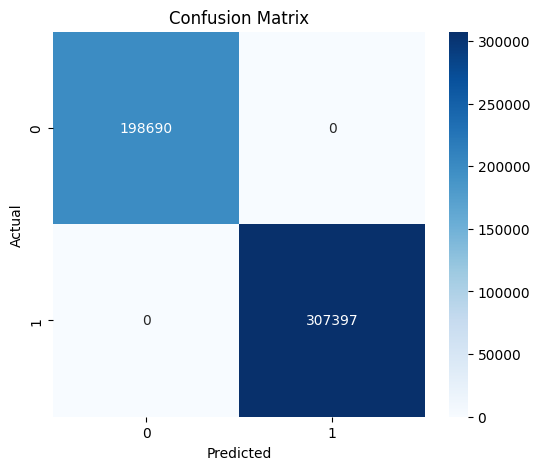

In [9]:
# =========================================================
# STEP 8 — CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [10]:
# =========================================================
# STEP 9 — SHAP EXPLAINER
# =========================================================

explainer = shap.TreeExplainer(model)

print("SHAP Explainer Created")

SHAP Explainer Created


In [11]:
# =========================================================
# STEP 10 — SAMPLE DATA FOR SHAP
# =========================================================

X_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

print(X_sample.shape)

(1000, 73)


In [12]:
# =========================================================
# STEP 11 — COMPUTE SHAP VALUES
# =========================================================

shap_values = explainer.shap_values(
    X_sample
)

print("SHAP Values Computed")

SHAP Values Computed


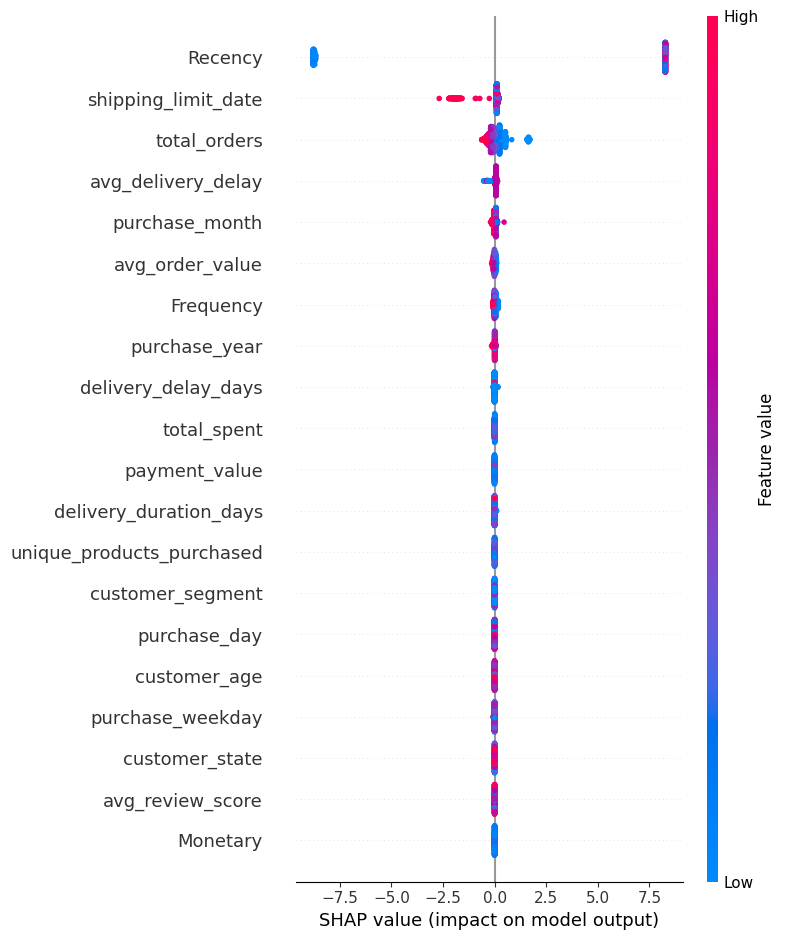

In [13]:
# =========================================================
# STEP 12 — SHAP SUMMARY PLOT
# =========================================================

shap.summary_plot(
    shap_values,
    X_sample
)

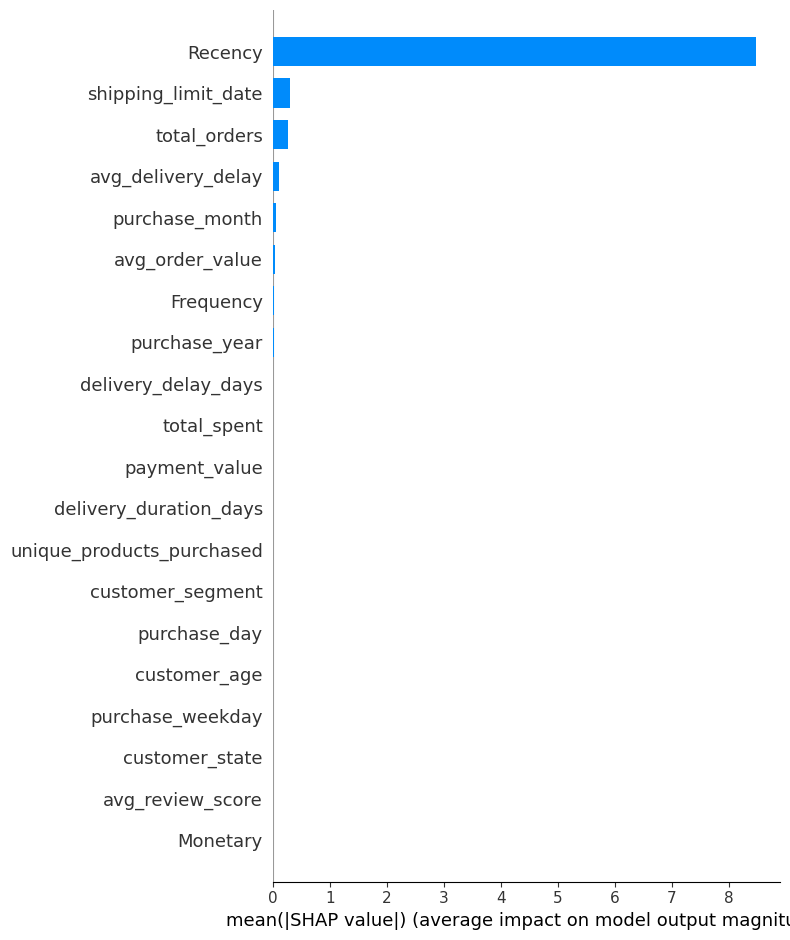

In [14]:
# =========================================================
# STEP 13 — FEATURE IMPORTANCE PLOT
# =========================================================

shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar'
)

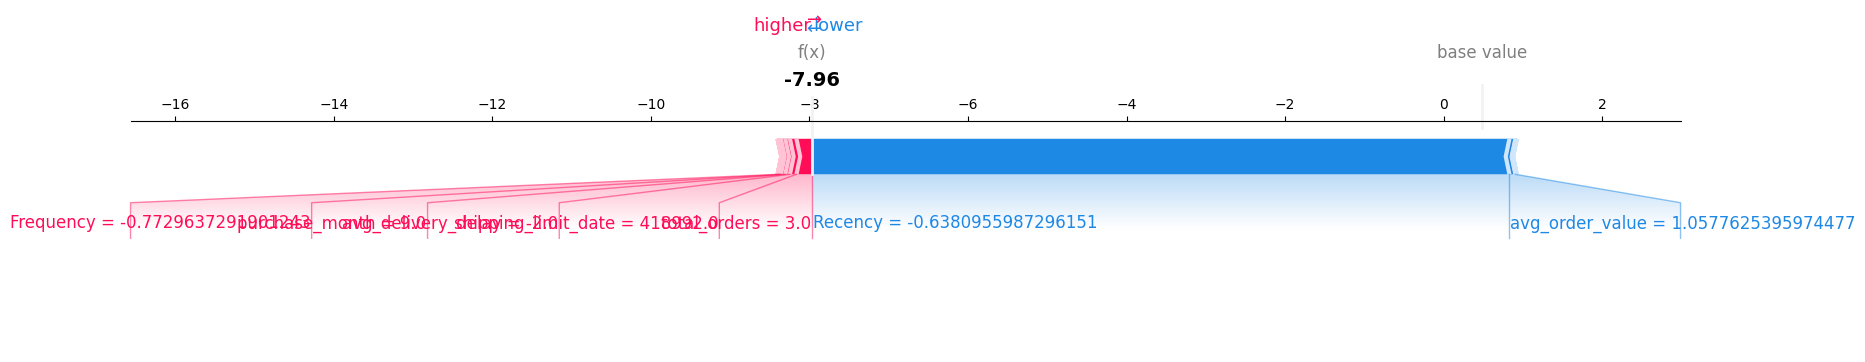

In [15]:
# =========================================================
# STEP 14 — SINGLE PREDICTION EXPLANATION
# =========================================================

sample_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_sample.iloc[sample_index],
    matplotlib=True
)

Top Feature: Recency


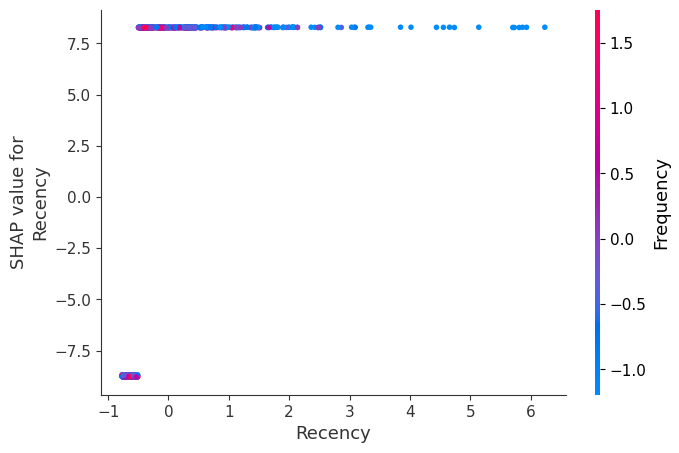

In [16]:
# =========================================================
# STEP 15 — DEPENDENCE PLOT
# =========================================================

top_feature = X_sample.columns[
    np.argmax(
        np.abs(shap_values).mean(0)
    )
]

print("Top Feature:", top_feature)

shap.dependence_plot(
    top_feature,
    shap_values,
    X_sample
)

In [17]:
# =========================================================
# STEP 16 — FEATURE IMPORTANCE DATAFRAME
# =========================================================

feature_importance = pd.DataFrame({

    'feature': X_sample.columns,

    'importance': np.abs(
        shap_values
    ).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

feature_importance.head(20)

,feature,importance
62,Recency,8.473026
14,shipping_limit_date,0.305942
56,total_orders,0.278003
60,avg_delivery_delay,0.104142
4,purchase_month,0.065117
58,avg_order_value,0.037449
63,Frequency,0.031200
5,purchase_year,0.023413
2,delivery_delay_days,0.007668
57,total_spent,0.005157


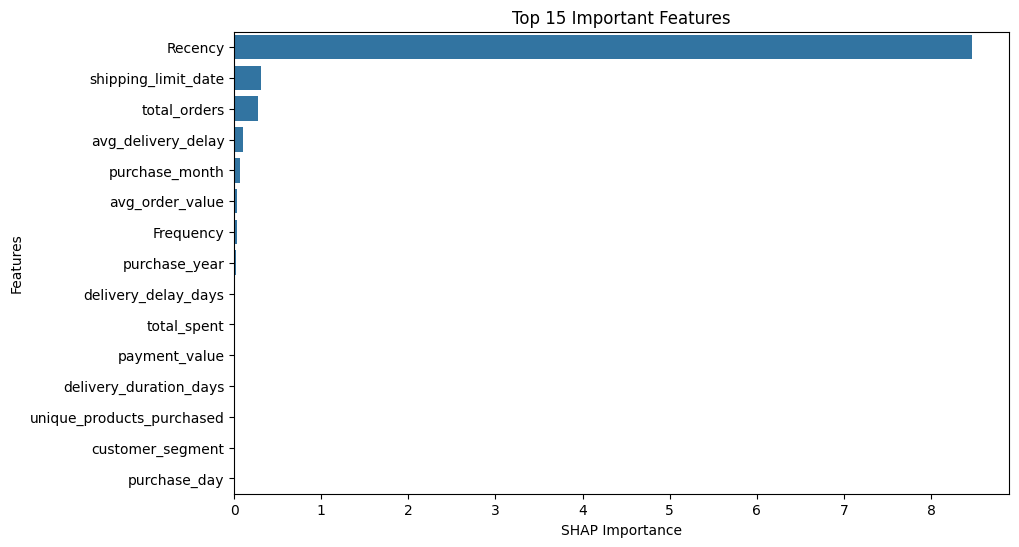

In [18]:
# =========================================================
# STEP 17 — TOP FEATURES VISUALIZATION
# =========================================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='importance',
    y='feature',
    data=top_features
)

plt.title("Top 15 Important Features")

plt.xlabel("SHAP Importance")

plt.ylabel("Features")

plt.show()

In [ ]:
# =========================================================
# STEP 18 — SAVE MODEL
# =========================================================

joblib.dump(
    model,
    MODELS_DIR / "xgboost_shap_model.pkl"
)

print("SHAP Model Saved Successfully")

Model Saved Successfully


In [20]:
# =========================================================
# STEP 19 — BUSINESS INSIGHTS
# =========================================================

print("""

===================================================

BUSINESS INSIGHTS

===================================================

1. Built Explainable AI (XAI) pipeline using SHAP.

2. Explained churn prediction behavior using feature attribution.

3. Identified top business drivers affecting churn.

4. Generated:
   - Global explanations
   - Local explanations
   - Feature importance insights

5. Improved AI transparency and interpretability.

6. Used:
   - XGBoost
   - SHAP Explainability
   - Feature attribution analysis

7. System supports:
   - Business decision intelligence
   - Explainable customer analytics
   - Responsible AI practices

===================================================

""")




BUSINESS INSIGHTS


1. Built Explainable AI (XAI) pipeline using SHAP.

2. Explained churn prediction behavior using feature attribution.

3. Identified top business drivers affecting churn.

4. Generated:
   - Global explanations
   - Local explanations
   - Feature importance insights

5. Improved AI transparency and interpretability.

6. Used:
   - XGBoost
   - SHAP Explainability
   - Feature attribution analysis

7. System supports:
   - Business decision intelligence
   - Explainable customer analytics
   - Responsible AI practices





In [21]:
# =========================================================
# STEP 20 — NOTEBOOK COMPLETION
# =========================================================

print("""

===================================================
15_explainable_ai_shap.ipynb COMPLETED SUCCESSFULLY
===================================================

""")



15_explainable_ai_shap.ipynb COMPLETED SUCCESSFULLY


